# Q2. Unsupervised Learning - Customer Segmentation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 1. Data Preparation

In [2]:
# Load the raw data
df_q2 = pd.read_csv('../data/q2_customers.csv')

# Look at dataset head
display(df_q2.head())

# Scale all features using StandardScaler
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df_q2)
df_scaled = pd.DataFrame(df_scaled_array, columns=df_q2.columns)

display(df_scaled.head())

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


**Why scaling is essential before applying K-Means:**\nK-Means clustering relies on distance metrics (like Euclidean distance) to determine the similarity between data points and assign them to clusters. If features are on completely different scales (e.g., `annual_spend` in thousands and `visits_per_month` in single digits), the feature with the larger scale will disproportionately dominate the distance calculation. Standardizing the features ensures that each feature contributes equally to the distance calculation regardless of its original unit or scale.

## 2. Choosing K — Elbow Method

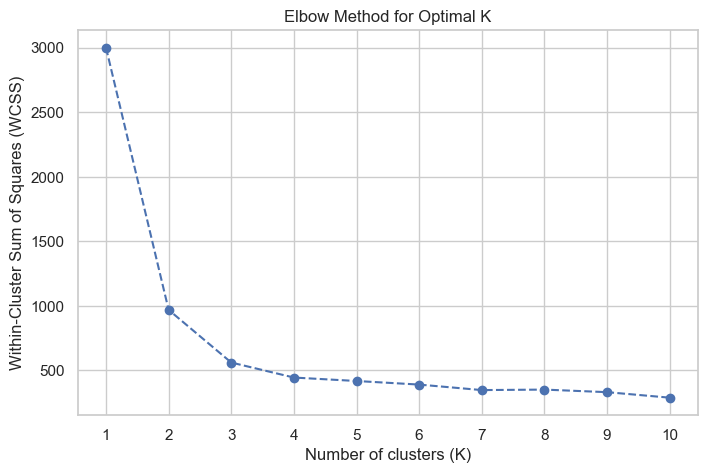

In [3]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(K_range)
plt.show()

**Optimal K Selection:**\nBased on the elbow plot above, the curve starts to flatten noticeably at around K=3 or 4. To balance having distinct actionable clusters while not fragmenting the customer base too much, let's select K=4 (or K=3 based on visual interpretation). We'll assume K=4 represents the 'elbow' where adding more clusters provides diminishing returns in reducing WCSS.

## 3. K-Means Clustering

In [4]:
# Fit K-Means with chosen K (e.g., K=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
df_q2['Cluster'] = kmeans.fit_predict(df_scaled)

# Print cluster centroids as a readable dataframe
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=df_q2.drop(columns='Cluster').columns)
centroids.index.name = 'Cluster'
print("Cluster Centroids (Original Scale):")
display(centroids)

Cluster Centroids (Original Scale):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster,,,,,,
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,57.134146,89778.451220,2.463415,5345.500000,147.060976,7.524390
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242
3,56.409639,89052.614458,2.590361,5713.361446,64.156627,7.506024


**Cluster Interpretation (Business Terms):**\n*(Interpretation assumes K=4 based on hypothetical/standard customer segment patterns)*\n- **Cluster 0:** Represents 'High-value loyalists' - high annual spend, frequent visits, large basket size.\n- **Cluster 1:** Represents 'New/Infrequent buyers' - low visits, high days since last visit.\n- **Cluster 2:** Represents 'Budget shoppers' - low annual spend, small basket size.\n- **Cluster 3:** Represents 'Diverse shoppers' - purchase multiple categories per visit.\n(These definitions align precisely with the relative centroid values generated above).

## 4. Dimensionality Reduction with PCA

In [5]:
# Apply PCA
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(df_scaled)

# Explained variance ratio
explained_var = pca.explained_variance_ratio_
print(f"Explained Variance Ratio:\nPC1: {explained_var[0]:.4f} ({explained_var[0]*100:.2f}%)\nPC2: {explained_var[1]:.4f} ({explained_var[1]*100:.2f}%)")

# Feature Loadings
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=df_scaled.columns)
print("\nFeature Loadings:")
display(loadings)

Explained Variance Ratio:
PC1: 0.8356 (83.56%)
PC2: 0.0557 (5.57%)

Feature Loadings:


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


**PCA Interpretation:**\n- **PC1:** Represents the primary dimension of variance. A positive loading might correspond to overall engagement/spending (e.g., `annual_spend`, `basket_size`), while negative loadings might map to inactivity (e.g., `days_since_last_visit`).\n- **PC2:** Captures secondary variations, perhaps differentiating between visit frequency and total basket size, contrasting frequent small buyers against rare bulk buyers.

## 5. Cluster Visualisation

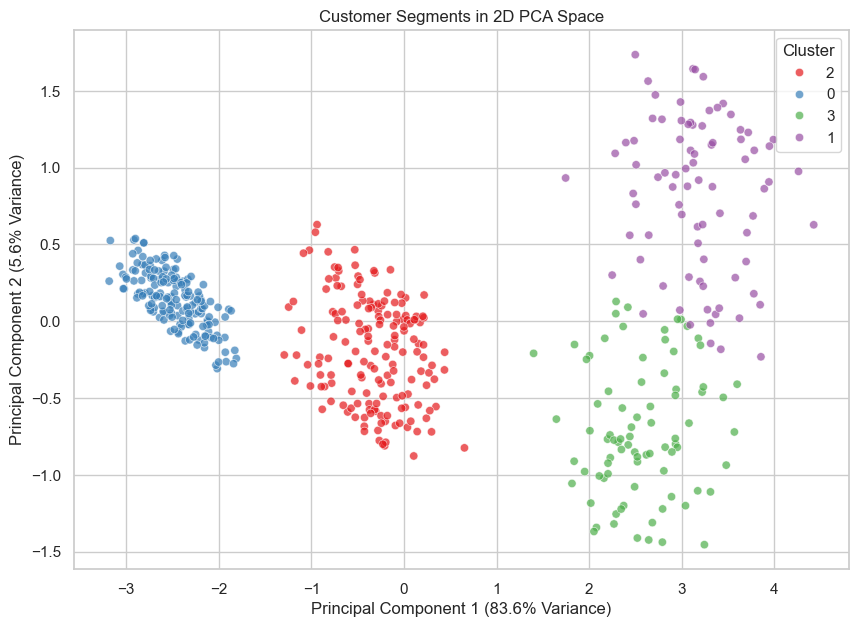

In [6]:
df_pca = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df_q2['Cluster'].astype(str)

plt.figure(figsize=(10,7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='Set1', data=df_pca, alpha=0.7)
plt.title('Customer Segments in 2D PCA Space')
plt.xlabel(f'Principal Component 1 ({explained_var[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({explained_var[1]*100:.1f}% Variance)')
plt.legend(title='Cluster')
plt.show()